In [1]:
import os
os.chdir('../..')

In [2]:
import polars as pl
from rdkit import Chem
from rdkit.Chem import Draw
from src.datasets import QM9Dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2026-02-24 15:46:28.885 | INFO     | utils.file_ops:get_device:36 - Using Apple Silicon (MPS)


In [3]:
qm9 = QM9Dataset()
qm9.load(force_process=False)
qm9.df.head(5)

2026-02-24 15:46:30.455 | INFO     | src.datasets:load:62 - Loading QM9 from data/QM9/dataset_cleaned.csv...


mol_id,smiles,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C
str,str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""qm9_679""","""[H]C([H])([H])[C@@]1([H])C([H]…","""[H]C([H])([H])[C@@]1([H])C([H]…","""[H][C][Branch1][C][H][Branch1]…",14,"""Aliphatic Ring""",84.118,0.7936,12.53,6,2,0,1,1.0,0,1,5,0,0,5,5,30,0,0,0,0,0,0,0,0,1,0,1,1.8181,52.619999,-6.813731,2.429977,9.243708,504.205505,3.259461,-7357.804199,-7357.652344,-7357.626465,-7358.584473,21.007999,-56.972103,-57.359951,-57.694107,-53.047516,6.51241,3.58887,2.9665
"""qm9_2151""","""[H]O[C@@]1([H])[C@@]([H])(C([H…","""[H]O[C@@]1([H])[C@@]([H])(C([H…","""[H][O][C@@][Branch1][C][H][C@@…",19,"""Aliphatic Ring""",100.161,1.0232,20.23,7,1,0,3,1.0,1,1,6,0,0,6,6,41,0,1,0,0,0,0,0,0,0,0,1,1.4024,66.360001,-6.772914,1.670779,8.443693,776.933899,4.654889,-8460.367188,-8460.149414,-8460.123047,-8461.231445,30.163,-75.220467,-75.733788,-76.196487,-69.823311,3.12009,2.54906,1.95743
"""qm9_558""","""[H]OC([H])([H])C1([H])C([H])([…","""[H]OC([H])([H])C1([H])C([H])([…","""[H][O][C][Branch1][C][H][Branc…",16,"""Aliphatic Ring""",86.134,0.7788,20.23,6,1,0,2,1.0,1,1,5,0,0,5,6,34,0,1,0,0,0,0,0,0,0,0,1,1.2955,56.810001,-7.110335,2.108882,9.219218,673.367493,3.903283,-7391.058594,-7390.878418,-7390.852539,-7391.883301,23.882999,-63.000675,-63.437069,-63.822624,-58.540352,8.32944,2.22945,1.91437
"""qm9_746""","""[H]C1=NN([H])C([H])=C1N([H])[H…","""[H]c1nn([H])c([H])c1N([H])[H]""","""[H][C][=N][N][Branch1][C][H][C…",11,"""Aromatic""",83.094,-0.0081,54.7,6,1,1,1,0.0,2,2,5,0,3,0,5,19,0,0,0,1,0,0,0,0,0,0,3,2.6547,47.66,-5.322547,0.819063,6.14161,479.686401,2.390765,-7659.477051,-7659.33252,-7659.306641,-7660.25,19.370001,-45.914295,-46.193863,-46.450878,-42.82338,9.31893,3.50517,2.55541
"""qm9_498""","""[H]C(=O)C([H])([H])C#CC([H])([…","""[H]C(=O)C([H])([H])C#CC([H])([…","""[H][C][=Branch1][C][=O][C][Bra…",12,"""Acyclic""",82.102,0.5987,17.07,6,0,0,1,0.4,0,1,3,2,1,2,6,22,0,0,0,0,0,0,0,0,0,0,1,2.7868,55.380001,-6.702164,-0.731986,5.970178,887.423401,2.541897,-7325.810059,-7325.606934,-7325.581055,-7326.721191,23.348,-52.204395,-52.463882,-52.746613,-48.990513,16.144159,1.34674,1.28155


In [4]:
qm9.df

mol_id,smiles,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C
str,str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""qm9_679""","""[H]C([H])([H])[C@@]1([H])C([H]…","""[H]C([H])([H])[C@@]1([H])C([H]…","""[H][C][Branch1][C][H][Branch1]…",14,"""Aliphatic Ring""",84.118,0.7936,12.53,6,2,0,1,1.0,0,1,5,0,0,5,5,30,0,0,0,0,0,0,0,0,1,0,1,1.8181,52.619999,-6.813731,2.429977,9.243708,504.205505,3.259461,-7357.804199,-7357.652344,-7357.626465,-7358.584473,21.007999,-56.972103,-57.359951,-57.694107,-53.047516,6.51241,3.58887,2.9665
"""qm9_2151""","""[H]O[C@@]1([H])[C@@]([H])(C([H…","""[H]O[C@@]1([H])[C@@]([H])(C([H…","""[H][O][C@@][Branch1][C][H][C@@…",19,"""Aliphatic Ring""",100.161,1.0232,20.23,7,1,0,3,1.0,1,1,6,0,0,6,6,41,0,1,0,0,0,0,0,0,0,0,1,1.4024,66.360001,-6.772914,1.670779,8.443693,776.933899,4.654889,-8460.367188,-8460.149414,-8460.123047,-8461.231445,30.163,-75.220467,-75.733788,-76.196487,-69.823311,3.12009,2.54906,1.95743
"""qm9_558""","""[H]OC([H])([H])C1([H])C([H])([…","""[H]OC([H])([H])C1([H])C([H])([…","""[H][O][C][Branch1][C][H][Branc…",16,"""Aliphatic Ring""",86.134,0.7788,20.23,6,1,0,2,1.0,1,1,5,0,0,5,6,34,0,1,0,0,0,0,0,0,0,0,1,1.2955,56.810001,-7.110335,2.108882,9.219218,673.367493,3.903283,-7391.058594,-7390.878418,-7390.852539,-7391.883301,23.882999,-63.000675,-63.437069,-63.822624,-58.540352,8.32944,2.22945,1.91437
"""qm9_746""","""[H]C1=NN([H])C([H])=C1N([H])[H…","""[H]c1nn([H])c([H])c1N([H])[H]""","""[H][C][=N][N][Branch1][C][H][C…",11,"""Aromatic""",83.094,-0.0081,54.7,6,1,1,1,0.0,2,2,5,0,3,0,5,19,0,0,0,1,0,0,0,0,0,0,3,2.6547,47.66,-5.322547,0.819063,6.14161,479.686401,2.390765,-7659.477051,-7659.33252,-7659.306641,-7660.25,19.370001,-45.914295,-46.193863,-46.450878,-42.82338,9.31893,3.50517,2.55541
"""qm9_498""","""[H]C(=O)C([H])([H])C#CC([H])([…","""[H]C(=O)C([H])([H])C#CC([H])([…","""[H][C][=Branch1][C][=O][C][Bra…",12,"""Acyclic""",82.102,0.5987,17.07,6,0,0,1,0.4,0,1,3,2,1,2,6,22,0,0,0,0,0,0,0,0,0,0,1,2.7868,55.380001,-6.702164,-0.731986,5.970178,887.423401,2.541897,-7325.810059,-7325.606934,-7325.581055,-7326.721191,23.348,-52.204395,-52.463882,-52.746613,-48.990513,16.144159,1.34674,1.28155
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_1702""","""[H]N1C([H])([H])[C@]1(C([H])([…","""[H]N1C([H])([H])[C@]1(C([H])([…","""[H][N][C][Branch1][C][H][Branc…",18,"""Aliphatic Ring""",101.149,-0.0053,31.17,7,1,0,4,1.0,1,2,6,0,0,5,6,38,0,0,0,0,0,0,0,0,1,0,2,2.4831,64.790001,-6.386512,2.212286,8.598799,901.865601,4.330229,-8896.571289,-8896.347656,-8896.322266,-8897.452148,29.250999,-69.597374,-70.067726,-70.504707,-64.494423,5.07931,1.70906,1.44845
"""qm9_881""","""[H]C1=NC(C([H])([H])[H])=C([H]…","""[H]c1nc(C([H])([H])[H])c([H])n…","""[H][C][=N][C][Branch1][=Branch…",15,"""Aromatic""",96.133,0.72852,17.82,7,1,1,2,0.4,0,2,6,0,3,2,6,29,0,0,0,0,0,0,0,0,0,0,2,3.5741,63.830002,-5.774256,0.998658,6.775635,777.963501,3.435709,-8292.504883,-8292.311523,-8292.285156,-8293.359375,24.914,-63.679218,-64.063446,-64.423294,-59.417236,7.22374,2.01491,1.60711
"""qm9_384""","""[H]OC([H])(C([H])([H])C([H])([…","""[H]OC([H])(C([H])([H])C([H])([…","""[H][O][C][Branch1][C][H][Branc…",18,"""Acyclic""",88.15,1.1673,20.23,6,0,0,5,1.0,1,1,5,0,0,5,6,38,0,1,0,0,0,0,0,0,0,0,1,1.4336,60.240002,-7.132104,1.961941,9.094045,805.738586,4.479702,-7424.485352,-7424.264648,-7424.23877,-7425.347656,28.827999,-69.200989,-

In [7]:
qm9.df.filter(pl.col("canonical_smiles").is_duplicated())

mol_id,smiles,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C
str,str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


# Visualization of a few molecules
- Ensuring that SMILES works for generating unique identifiers for each molecule

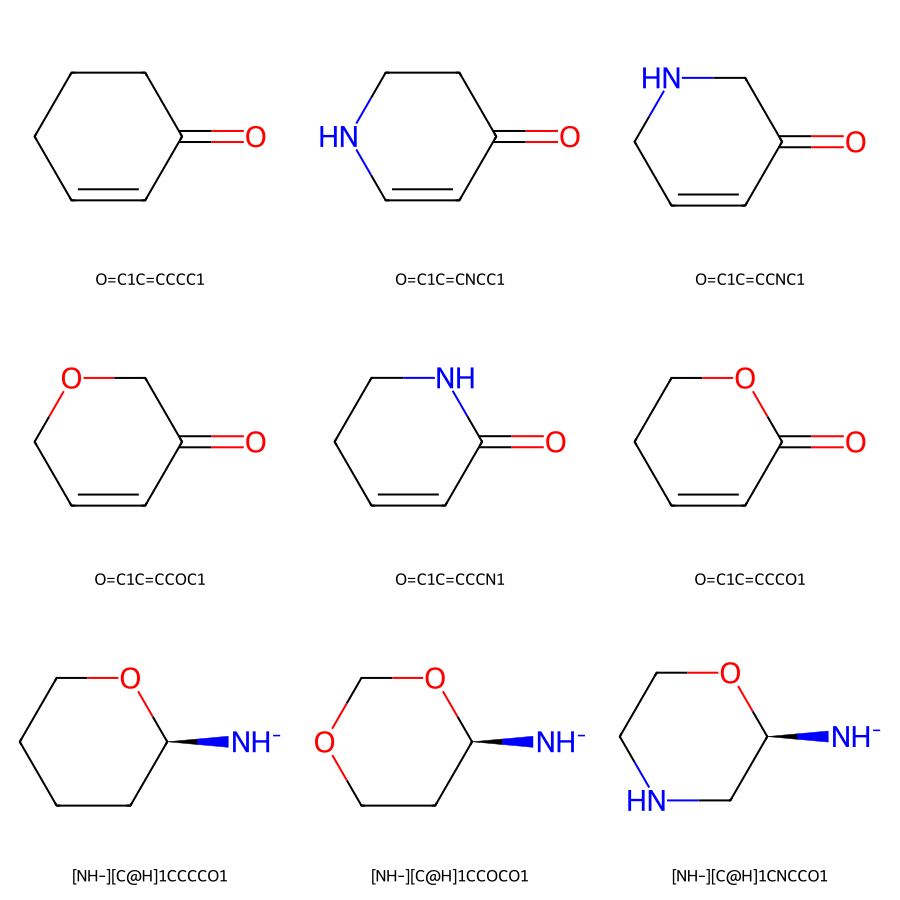

In [ ]:
sample_smiles = qm9.df.tail(9)["canonical_smiles"].to_list()
mols = [Chem.MolFromSmiles(s) for s in sample_smiles]

img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300), legends=sample_smiles)
img

# Figures for report

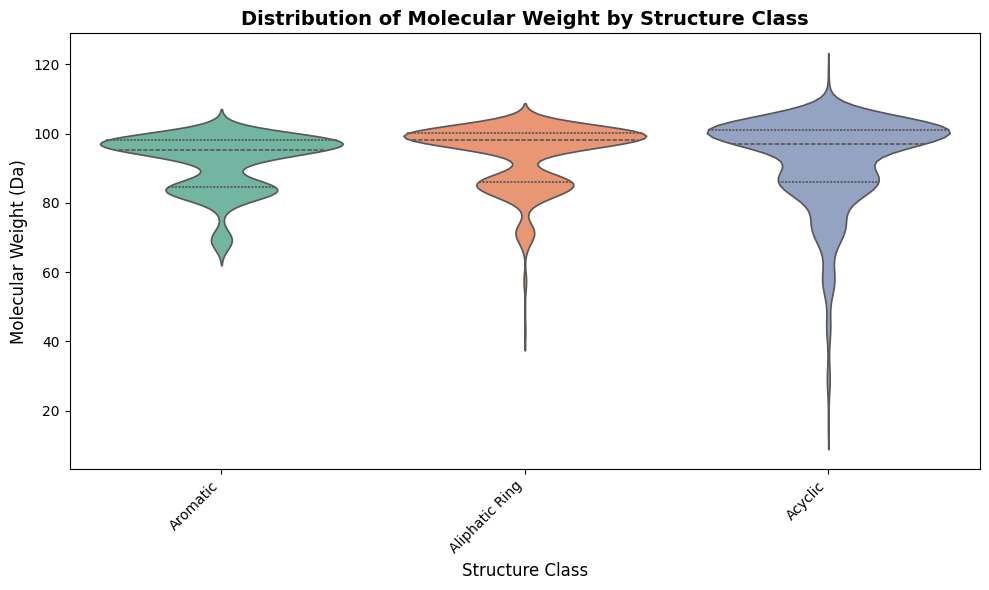

In [8]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=qm9.df, 
    x='structure_class', 
    y='mol_weight', 
    palette='Set2', 
    hue='structure_class',
    inner='quartile'
)
plt.title('Distribution of Molecular Weight by Structure Class', fontsize=14, fontweight='bold')
plt.xlabel('Structure Class', fontsize=12)
plt.ylabel('Molecular Weight (Da)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

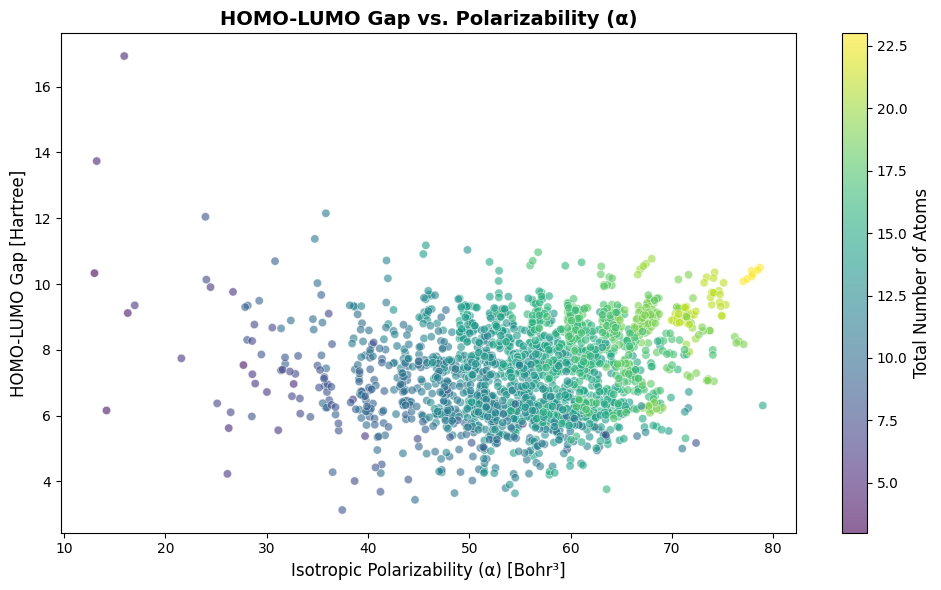

In [9]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    qm9.df['alpha'], 
    qm9.df['gap'], 
    c=qm9.df['num_atoms'], 
    cmap='viridis', 
    alpha=0.6,
    edgecolors='w',
    linewidth=0.5
)
cbar = plt.colorbar(scatter)
cbar.set_label('Total Number of Atoms', fontsize=12)

plt.title('HOMO-LUMO Gap vs. Polarizability (α)', fontsize=14, fontweight='bold')
plt.xlabel('Isotropic Polarizability (α) [Bohr³]', fontsize=12)
plt.ylabel('HOMO-LUMO Gap [Hartree]', fontsize=12)
plt.tight_layout()
plt.show()

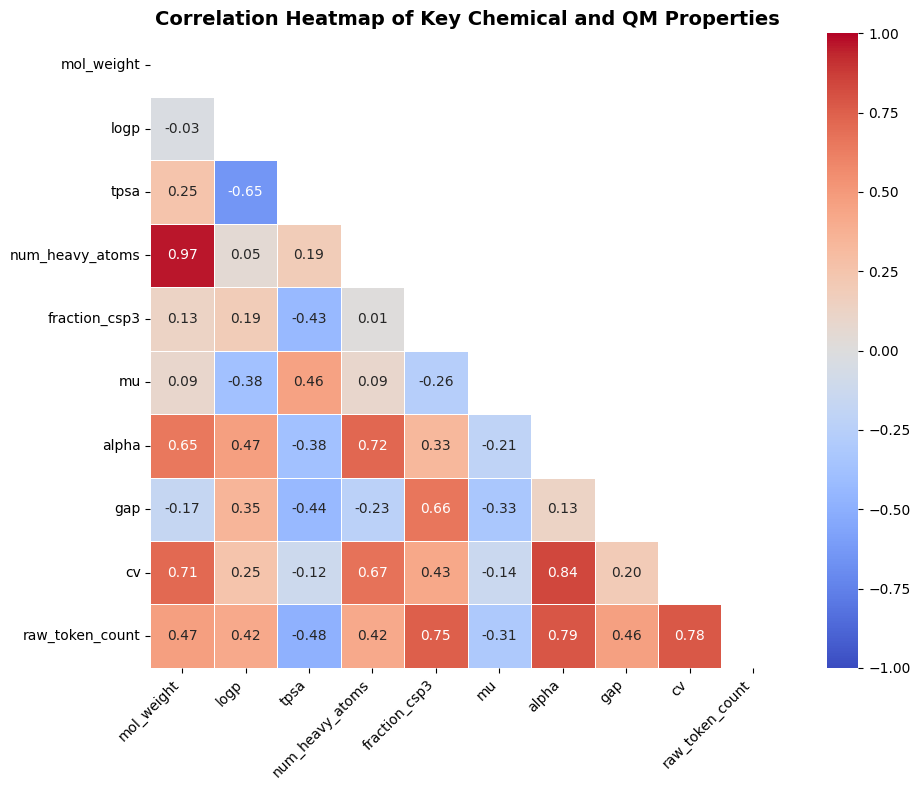

In [14]:
plt.figure(figsize=(10, 8))

# Select a mix of 2D cheminformatics features and 3D quantum features
features_of_interest = [
    'mol_weight', 'logp', 'tpsa', 'num_heavy_atoms', 
    'fraction_csp3', 'mu', 'alpha', 'gap', 'cv', 'raw_token_count'
]

# Calculate Spearman correlation (better for potentially non-linear chemical features)
corr = qm9.df[features_of_interest].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    square=True,
    xticklabels=features_of_interest,   # ← use names instead of 0,1,2…
    yticklabels=features_of_interest
)

plt.xticks(rotation=45, ha='right')      # if you want them tilted
plt.title('Correlation Heatmap of Key Chemical and QM Properties', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
qm9.df['structure_class']

structure_class
str
"""Aromatic"""
"""Aliphatic Ring"""
"""Aliphatic Ring"""
"""Aliphatic Ring"""
"""Acyclic"""
…
"""Acyclic"""
"""Aromatic"""
"""Acyclic"""


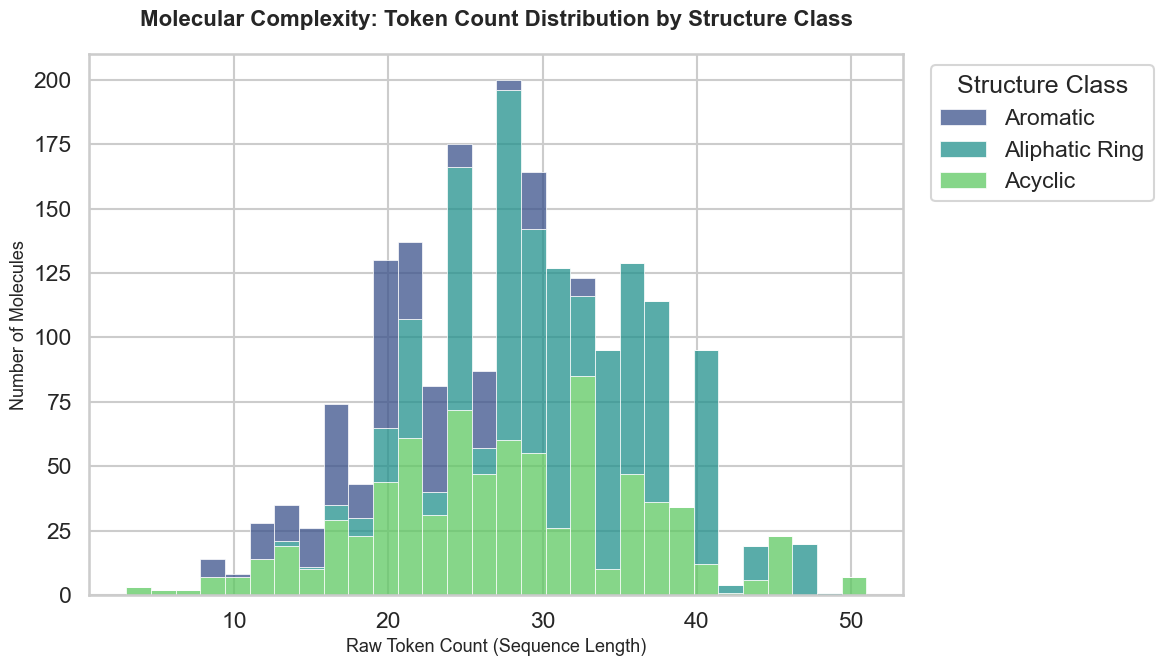

In [20]:
plt.figure(figsize=(12, 7))

# 1. Create the plot (Seaborn creates the legend automatically here)
ax = sns.histplot(
    data=qm9.df,
    x='raw_token_count',
    hue='structure_class',
    multiple='stack',
    palette='viridis',
    edgecolor='white',
    linewidth=0.5,
    bins=30
)

# 2. Access the auto-generated legend and move it
# This avoids the "No artists with labels found" warning
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title='Structure Class')

plt.title('Molecular Complexity: Token Count Distribution by Structure Class', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Raw Token Count (Sequence Length)', fontsize=13)
plt.ylabel('Number of Molecules', fontsize=13)

plt.tight_layout()
plt.savefig('report/qm9/figures/initial_analysis/plot_token_count_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

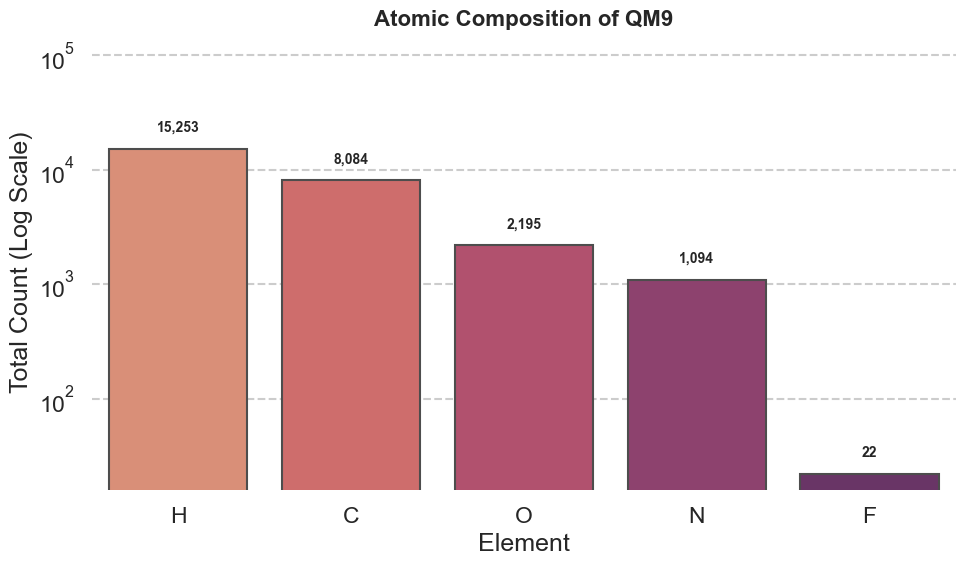

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# 1. Processing - Using map(str) to avoid the AttributeError
all_smiles = "".join(map(str, qm9.df["canonical_smiles"]))

# Regex: Find Capital letters followed by optional lowercase (Elements)
# We filter out common SMILES syntax that isn't an element
tokens = re.findall(r'[A-Z][a-z]?', all_smiles)
valid_elements = {'H', 'C', 'N', 'O', 'F', 'S', 'Cl', 'P', 'Br', 'I'}
atom_counts = Counter([t for t in tokens if t in valid_elements])

comp_df = pd.DataFrame(atom_counts.items(), columns=['Element', 'Count'])
comp_df = comp_df.sort_values('Count', ascending=False)

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid", {'axes.grid' : True, 'grid.linestyle': '--'})

ax = sns.barplot(
    data=comp_df, 
    x='Element', 
    y='Count', 
    palette='flare',
    hue='Element',
    edgecolor='0.3'
)

ax.set_yscale("log")
plt.ylim(top=comp_df['Count'].max() * 10) # Added more headroom for labels

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.title('Atomic Composition of QM9', fontsize=16, fontweight='bold')
plt.ylabel('Total Count (Log Scale)')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('report/qm9/figures/initial_analysis/atomic_composition.png', dpi=300, bbox_inches='tight')
plt.show()